# Iterative feature engineering
This category is too different than the others, we begun using statistical tests to select significant features in our dataset, saw another methods like clustering algorithms to add complex relationships, dimensional reductions and embedded methods in some ML algoritms. To conclude with feature engineering series, let's see an approach specially aimed for parameter tunning in specific models.  
Iterative methods (also called wrapper methods) works evaluating subsets of features by training a ML model and measuring its performance with each subset, then the best subset is chosen from best model performance.

**Considerations:**
- Try to perform cross validation to avoid overfitting or lucky training/testing splits.
- Set early stopping in algorithms like: neural nets, SVM or gradient based algorithms or enable regularization techniques.
- Computation time is high as we are testing with many subsets of our dataset.
- Use when you want a feature set tailored specifically to a certain model and you want high metrics.
- Not recommended for high dimension data (execution scales exponentialy).

## Recursive feature elimination (RFE)
Consists on training the model using the entire dataset, then ranks all features based on their importance (like embedded method) and recursively removes least importat ones and retrains the model. This procedure is repeated until desired number of features is reached. To measure feature importance, RFE uses measures from the estimator (like embedded methods).  
**Note:** Scikit provides `RFE` class to classic algorithm (without cross-validation) and `RFECV` for cross-validation variant. Cross validated variant uses models metrics instead internal algorithm feature importance criterion.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from pandas import read_csv

DATA = read_csv("/kaggle/input/datasets/debayank2024/house-price-prediction/modified_data.csv")
NUMS = ["sqft_living", "bathrooms", "bedrooms", "sqft_lot", "floors", "sqft_above", "sqft_basement", "yr_built", "price_per_sqft"]
CATS = ["waterfront", "view", "condition"]
TARGET = "price"

data = DATA.drop(columns=["street"])
x = data[NUMS + CATS + ["city", "statezip"]]

TRANSFORMER = ColumnTransformer([
    ("standarized", StandardScaler(), NUMS),
    ("encoding", OrdinalEncoder(), ["city", "statezip"])
], verbose_feature_names_out=False, remainder="passthrough")

TRANSFORMER.set_output(transform="pandas")

X = TRANSFORMER.fit_transform(x)
y = data[TARGET]

In [13]:
from sklearn.feature_selection import RFECV

MODEL_RFE = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)

RFE_SELECTOR = RFECV(MODEL_RFE, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
RFE_SELECTOR.fit(X, y)

print("Selected features (RFE): ", RFE_SELECTOR.get_feature_names_out())

Selected features (RFE):  ['sqft_living' 'yr_built' 'price_per_sqft']


## Sequential elimination
Works on the same way as RFE but with some differences, in category we have 2 approaches:
- **Forward selection:** Starts with an empty dataset, then trains the model using each single feature at time and selects the one that improves model performance most. Then repeats the process adding other feature and continues until reaching a defined number of features or when model performance doesn't improves.
- **Backward elimination:** Is the opposite, we start training the model with the entire dataset, then we remove one feature at time. Selected feature is removed after measuring that contributes least to the model. Continues on the same procedure until reaching desired feature amount or model performance downgrades.

Forward selection is recommended when you want only few features to be useful. While backward elimination works better for removing irrelevant or redundant features. As RFE, if cross validation is disabled, internal feature importance is used for selecting measures.

In [14]:
from sklearn.feature_selection import SequentialFeatureSelector

MODEL_FORWARD = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
MODEL_BACKWARD = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)

FORWARD_SELECTOR = SequentialFeatureSelector(MODEL_FORWARD, direction="forward", cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
FORWARD_SELECTOR.fit(X, y)

print("Selected features (Forward): ", FORWARD_SELECTOR.get_feature_names_out())

BACKWARD_SELECTOR = SequentialFeatureSelector(MODEL_BACKWARD, direction="backward", cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
BACKWARD_SELECTOR.fit(X, y)

print("Selected features (Backward): ", FORWARD_SELECTOR.get_feature_names_out())

Selected features (Forward):  ['sqft_living' 'floors' 'sqft_above' 'yr_built' 'price_per_sqft' 'view'
 'condition']
Selected features (Backward):  ['sqft_living' 'floors' 'sqft_above' 'yr_built' 'price_per_sqft' 'view'
 'condition']


In [15]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data[NUMS + CATS + ["city", "statezip"]], data[TARGET], test_size=0.2, random_state=123)

X_train = TRANSFORMER.fit_transform(x_train)
X_test = TRANSFORMER.transform(x_test)

VANILLA_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
RFE_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
FORWARD_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)
BACKWARD_MODEL = GradientBoostingRegressor(random_state=123, learning_rate=0.05, n_estimators=200)

VANILLA_MODEL.fit(X_train, y_train)
RFE_MODEL.fit(RFE_SELECTOR.transform(X_train), y_train)
FORWARD_MODEL.fit(FORWARD_SELECTOR.transform(X_train), y_train)
BACKWARD_MODEL.fit(BACKWARD_SELECTOR.transform(X_train), y_train)

VANILLA_PREDS = VANILLA_MODEL.predict(X_test)
RFE_PREDS = RFE_MODEL.predict(RFE_SELECTOR.transform(X_test))
FORWARD_PREDS = FORWARD_MODEL.predict(FORWARD_SELECTOR.transform(X_test))
BACKWARD_PREDS = BACKWARD_MODEL.predict(BACKWARD_SELECTOR.transform(X_test))

VANILLA_SQUARED_ERROR = mean_squared_error(y_test, VANILLA_PREDS)
RFE_SQUARED_ERROR = mean_squared_error(y_test, RFE_PREDS)
FORWARD_SQUARED_ERROR = mean_squared_error(y_test, FORWARD_PREDS)
BACKWARD_SQUARED_ERROR = mean_squared_error(y_test, BACKWARD_PREDS)

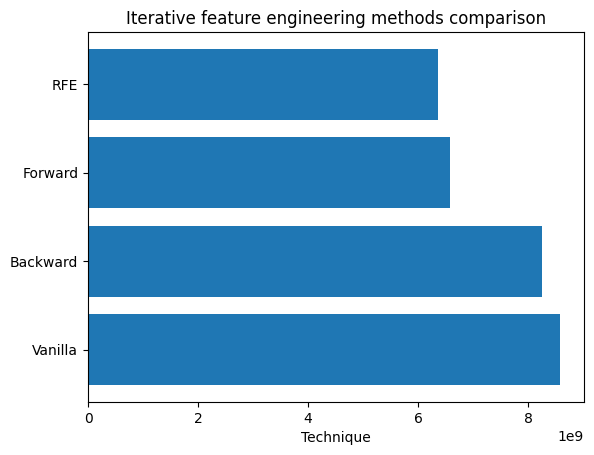

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.barh(["RFE", "Forward", "Backward", "Vanilla"], [RFE_SQUARED_ERROR, FORWARD_SQUARED_ERROR, BACKWARD_SQUARED_ERROR, VANILLA_SQUARED_ERROR])
ax.yaxis.set_inverted(True)
ax.set_xlabel('Technique')
ax.set_title('Iterative feature engineering methods comparison')

fig.show()